# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2381 Ивашинников Леонид и Двиков Даниил. Вариант №23

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Выборочная прямая среднеквадратической регрессии позволяет описать линейную зависимость между признаками $X$ и $Y$ по методу наименьших квадратов.

Прямая регрессии $Y$ на $X$ имеет вид

$$ŷ=a_{yx}+b_{yx}x,$$
где $b_{yx}=r_{xy}\frac{s_y}{s_x}$, $a_{yx}=ȳ-b_{yx}x̄$.

Прямая регрессии $X$ на $Y$ имеет вид
$$x̂=a_{xy}+b_{xy}y,$$
где $b_{xy}=r_{xy}\frac{s_x}{s_y}$, $a_{xy}=x̄-b_{xy}ȳ$.

Параболическая регрессия записывается формулой

$$ŷ=\beta_0+\beta_1x+\beta_2x^2$$

Выборочное корреляционное отношение используют для оценки тесноты не только линейной, но и произвольной связи. Для зависимости $Y$ от $X$:

$$\eta_{yx}=\sqrt{\frac{\sum_jn_j(ȳ_j-ȳ)^2}{\sum_i(y_i-ȳ)^2}}$$

## Постановка задачи

Для заданной двумерной выборки $(X,Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы


In [2]:
import pandas as pd


NU_HEADER, E_HEADER = 'nu (kg/cm^3)', 'E (kg/cm^2)'

df = pd.read_csv('/content/dataset.csv', sep=';')
df.describe()

,nu (kg/cm^3),E (kg/cm^2)
count,109.000000,109.000000
mean,0.449569,127.912844
std,0.054279,22.346406
min,0.320000,71.100000
25%,0.412000,114.800000
50%,0.448000,127.700000
75%,0.487000,143.800000
max,0.593000,187.400000


1. Отобразить двумерную выборку на графике.

Text(0, 0.5, 'E (kg/cm^2)')

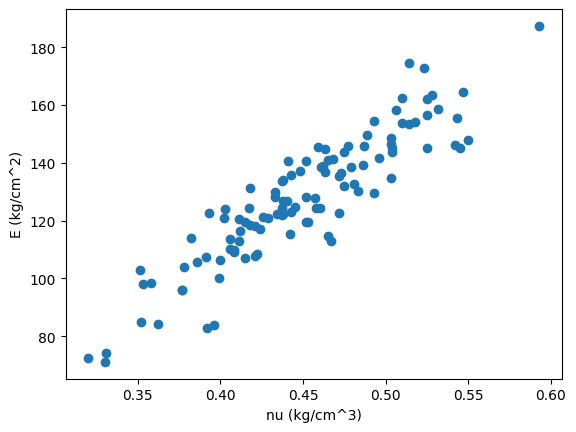

In [34]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1)
ax.scatter(df[NU_HEADER], df[E_HEADER])
ax.set_xlabel(NU_HEADER)
ax.set_ylabel(E_HEADER)

2. Для заданной выборки построить уравнения средней квадратичной регрессии $x$ на $y$ и $y$ на $x$ соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

Регрессия y на x: y = -40.53 + 374.67 * x
Регрессия x на y: x = 0.17 + 0.00 * y


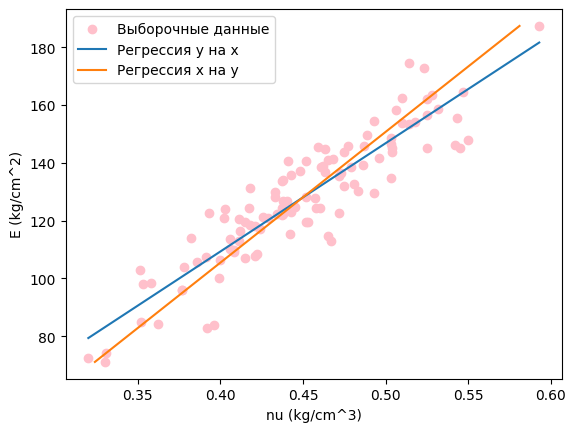

In [22]:
import numpy as np


x, y = df[NU_HEADER], df[E_HEADER]

mean_x, mean_y = np.mean(x), np.mean(y)
std_x, std_y = np.std(x, ddof=1), np.std(y, ddof=1)

r = np.corrcoef(x, y)[0, 1]

# Регрессия y на x.
b = r * std_y / std_x
a = mean_y - b * mean_x
x_values = np.linspace(min(x), max(x), 100)
y_reg = a + b * x_values

# Регрессия x на y.
d = r * std_x / std_y
c = mean_x - d * mean_y
y_values = np.linspace(min(y), max(y), 100)
x_reg = c + d * y_values

print(f'Регрессия y на x: y = {a:.2f} + {b:.2f} * x\nРегрессия x на y: x = {c:.2f} + {d:.2f} * y')

fig, ax = plt.subplots(1)
ax.scatter(x, y, color='pink', label='Выборочные данные')
ax.plot(x_values, y_reg, label='Регрессия y на x')
ax.plot(x_reg, y_values, label='Регрессия x на y')
ax.set_xlabel(NU_HEADER)
ax.set_ylabel(E_HEADER)
ax.legend()

Построенные прямые довольно точно описывают наблюдения. По графику видно, что линии регрессии пересекаются в точке, где значения обеих переменных равны среднему. Это связано с особенностями метода наименьших квадратов (с тем, что он гарантирует, что прямая будет проходить через среднее значение каждой из переменных).

3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy}\ge\left|r_{xy}\right|$ и $\eta_{yx}\ge\left|r_{xy}\right|$ выполняются.

In [31]:
from IPython.display import display, Markdown


k = int(1 + 3.322 * np.log10(len(df)))
bins_nu = pd.cut(df[NU_HEADER], bins=k, right=False)
bins_e = pd.cut(df[E_HEADER], bins=k, right=False)

contingency_table = pd.crosstab(bins_e, bins_nu, margins=True, margins_name="Total")

table = np.array(contingency_table)
intervals_nu = bins_nu.cat.categories
intervals_e = bins_e.cat.categories
weights_x = np.array([(interval.left + interval.right) / 2 for interval in intervals_nu])
weights_y = np.array([(interval.left + interval.right) / 2 for interval in intervals_e])

n_y = table[:-1, -1]
weighted_means_rows = []
for i in range(table.shape[0] - 1):
  row = table[i, :-1]
  weighted_mean = np.sum(row * weights_x) / n_y[i]
  weighted_means_rows.append(weighted_mean)

print('Условное выборочное среднее по строкам:', *np.round(weighted_means_rows, 4))

n_x = table[-1, :-1]
weighted_means_cols = []
for i in range(table.shape[1] - 1):
  col = table[i, :-1]
  weighted_mean = np.sum(col * weights_y) / n_x[i]
  weighted_means_cols.append(weighted_mean)

print('Условное выборочное среднее по столбцам:', *np.round(weighted_means_cols, 4))

contingency_table.rename(index={"Total": "$n_x$"}, columns={"Total": "$n_y$"}, inplace=True)
display(Markdown(contingency_table.to_markdown()))

Условное выборочное среднее по строкам: 0.3562 0.3674 0.4206 0.4504 0.4895 0.5215 0.5345
Условное выборочное среднее по столбцам: 86.5275 63.8921 113.9651 119.2038 186.3005 117.7052 487.4935


| E (kg/cm^2)        |   [0.32, 0.359) |   [0.359, 0.398) |   [0.398, 0.437) |   [0.437, 0.476) |   [0.476, 0.515) |   [0.515, 0.554) |   [0.554, 0.593) |   $n_y$ |
|:-------------------|----------------:|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|--------:|
| [71.1, 87.714)     |               4 |                3 |                0 |                0 |                0 |                0 |                0 |       7 |
| [87.714, 104.329)  |               3 |                3 |                1 |                0 |                0 |                0 |                0 |       7 |
| [104.329, 120.943) |               0 |                3 |               17 |                5 |                0 |                0 |                0 |      25 |
| [120.943, 137.557) |               0 |                1 |                7 |               20 |                4 |                0 |                0 |      32 |
| [137.557, 154.171) |               0 |                0 |                0 |                9 |               12 |                5 |                0 |      26 |
| [154.171, 170.786) |               0 |                0 |                0 |                0 |                3 |                6 |                0 |       9 |
| [170.786, 187.516) |               0 |                0 |                0 |                0 |                1 |                1 |                1 |       3 |
| $n_x$              |               7 |               10 |               25 |               34 |               20 |               12 |                1 |     109 |

In [32]:
x_bar_y = weighted_means_rows
y_bar_x = weighted_means_cols

n_total = np.sum(n_y)

mean_y = np.sum(n_y * x_bar_y) / n_total
var_y = np.sum(n_y * (x_bar_y - mean_y) ** 2) / n_total

mean_x = np.sum(n_x * y_bar_x) / n_total
var_x = np.sum(n_x * (y_bar_x - mean_x) ** 2) / n_total

y_pred = y_bar_x
var_y_pred = np.sum(n_x * (y_pred - mean_y) ** 2) / n_total

x_pred = x_bar_y
var_x_pred = np.sum(n_y * (x_pred - mean_x) ** 2) / n_total

eta_xy = np.sqrt(var_y_pred / var_y)
eta_yx = np.sqrt(var_x_pred / var_x)

cov_xy = np.sum(n_x * (y_bar_x - mean_x) * (x_bar_y - mean_y)) / n_total
r_xy = cov_xy / np.sqrt(var_x * var_y)

print(f"η_xy: {eta_xy:.4f}")
print(f"η_yx: {eta_yx:.4f}")
print(f"r_xy: {r_xy:.4f}")

print("Проверка неравенств:")
print(f"η_xy >= |r_xy|: {eta_xy >= abs(r_xy)}")
print(f"η_yx >= |r_xy|: {eta_yx >= abs(r_xy)}")

η_xy: 2883.4786
η_yx: 2.5835
r_xy: 0.6321
Проверка неравенств:
η_xy >= |r_xy|: True
η_yx >= |r_xy|: True


Корреляционное отношение $r_{xy}=0.63$ подтверждает наличие положительной связи между параметрами $\nu$ и $E$. Неравенства также выполняются.

4. Для заданной выборки построить корреляционную кривую параболического вида $y=\beta_0+\beta_1x+\beta_2x^2$, сделать выводы.

Коэффициенты параболической регрессии:
β_0 = -0.0665
β_1 = 0.9535
β_2 = 0.0305


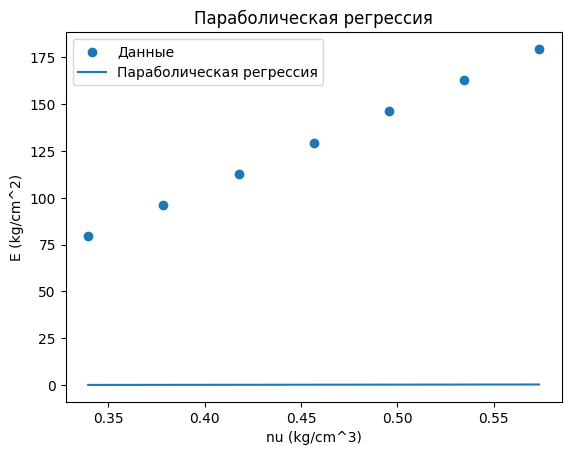

In [33]:
x_values = weights_x
y_values = weights_y

sum_x4 = np.sum(n_x * x_values ** 4)
sum_x3 = np.sum(n_x * x_values ** 3)
sum_x2 = np.sum(n_x * x_values ** 2)
sum_x = np.sum(n_x * x_values)

sum_yx2 = np.sum(n_x * weighted_means_rows * x_values ** 2)
sum_yx = np.sum(n_x * weighted_means_rows * x_values)
sum_y = np.sum(n_x * weighted_means_rows)

A = np.array([
    [sum_x4, sum_x3, sum_x2],
    [sum_x3, sum_x2, sum_x],
    [sum_x2, sum_x, np.sum(n_x)]
])
B = np.array([sum_yx2, sum_yx, sum_y])

# Решение системы
beta = np.linalg.solve(A, B)
beta_0, beta_1, beta_2 = beta

print(f"Коэффициенты параболической регрессии:")
print(f"β_0 = {beta_0:.4f}")
print(f"β_1 = {beta_1:.4f}")
print(f"β_2 = {beta_2:.4f}")

x_fit = np.linspace(min(x_values), max(x_values), 100)
y_fit = beta_0 + beta_1 * x_fit + beta_2 * x_fit ** 2

fig, ax = plt.subplots(1)
ax.scatter(x_values, y_values, label='Данные')
ax.plot(x_fit, y_fit, label='Регрессия')
ax.set_title('Параболическая регрессия')
ax.set_xlabel(NU_HEADER)
ax.set_ylabel(E_HEADER)
ax.legend()

Полученная регрессия значительно отклоняется от реальных значений. Это говорит о том, что параболическая регрессия не подходит. На самом деле, для выборки более характерна линейная зависимость.

5. Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:
e. обратно пропорциональная функция: $y=\beta_0+\frac{\beta_1}{x}$.

ŷ = 289.216785 + -71.438939/x


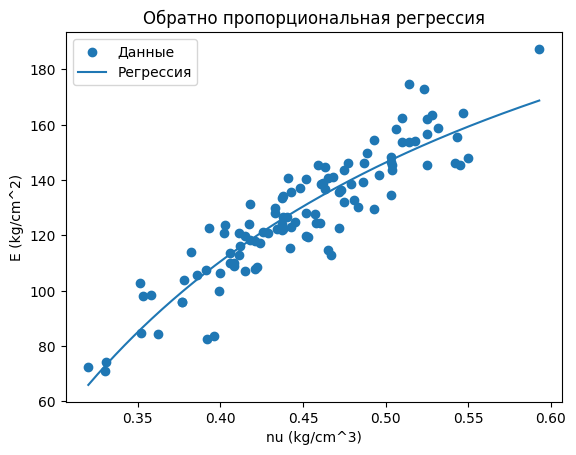

In [36]:
u = 1 / x
beta_1_inv = np.sum((u - np.mean(u)) * (y - np.mean(y))) / np.sum((u - np.mean(u)) ** 2)
beta_0_inv = np.mean(y) - beta_1_inv * np.mean(u)
y_inv = beta_0_inv + beta_1_inv / x

print(f"ŷ = {beta_0_inv:.6f} + {beta_1_inv:.6f}/x")

x_plot = np.linspace(np.min(x), np.max(x), 300)
y_plot = beta_0_inv + beta_1_inv / x_plot

fig, ax = plt.subplots(1)
ax.scatter(x, y, label="Данные")
ax.plot(x_plot, y_plot, label="Регрессия")
ax.set_xlabel(NU_HEADER)
ax.set_ylabel(E_HEADER)
ax.set_title("Обратно пропорциональная регрессия")
ax.legend()

Если сделать замену $u=\frac{1}{x}$, получим линейную зависимость $y=\beta_0+\beta_1u$. Параметры этой зависимости можно найти методом наименьших квадратов.

Получили кривую в виде обратно пропорциональной функции, которая визуально показывает хороший результат.

## Выводы

Были применены различные методы регрессионного анализа, например: линейная, параболическая и обратно пропорциональная регрессии. Был применён метод наименьших квадратов для поиска коэффициентов регрессий. Ввиду линейной зависимости хорошие результаты показала линейная регрессия. Также хороший результат показала обратно пропорциональная регрессия. Параболическая регрессия не смогла описать зависимость.